In [1]:
import pandas as pd
import numpy as np

nav = pd.read_csv("/workspaces/bluestock_mf_capstone/data/processed/clean_nav.csv")
transactions = pd.read_csv("/workspaces/bluestock_mf_capstone/data/processed/clean_transactions.csv")
performance = pd.read_csv("/workspaces/bluestock_mf_capstone/data/processed/clean_performance.csv")
holdings = pd.read_csv("/workspaces/bluestock_mf_capstone/data/raw/09_portfolio_holdings.csv")

In [2]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code","date"])

nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

In [3]:
risk_report = []

for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    var95 = np.percentile(returns,5)

    cvar95 = returns[returns <= var95].mean()

    risk_report.append([code,var95,cvar95])

risk_df = pd.DataFrame(
    risk_report,
    columns=["amfi_code","VaR_95","CVaR_95"]
)

risk_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [4]:
risk_df.to_csv(
    "/workspaces/bluestock_mf_capstone/data/processed/var_cvar_report.csv",
    index=False
)

In [6]:
top5 = performance.nlargest(
    5,
    "sharpe_ratio"
)["amfi_code"]

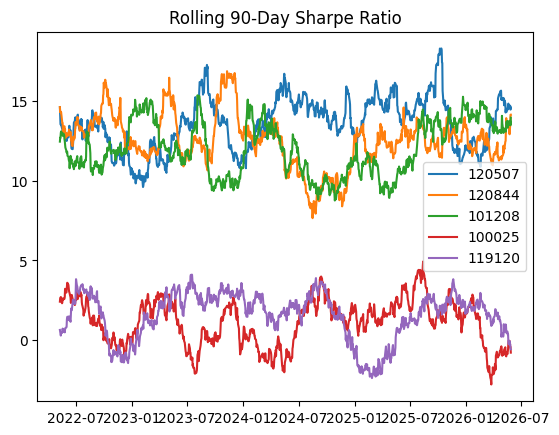

In [7]:
import matplotlib.pyplot as plt

for code in top5:

    temp = nav[nav["amfi_code"] == code].copy()

    temp["rolling_sharpe"] = (
        temp["daily_return"]
        .rolling(90)
        .mean()
        /
        temp["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=str(code)
    )

plt.legend()
plt.title("Rolling 90-Day Sharpe Ratio")
plt.show()

In [8]:
plt.savefig(
    "/workspaces/bluestock_mf_capstone/reports/rolling_sharpe_chart.png"
)

<Figure size 640x480 with 0 Axes>

In [9]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

first_txn = transactions.groupby(
    "investor_id"
)["transaction_date"].min()

transactions["cohort_year"] = (
    transactions["investor_id"]
    .map(first_txn.dt.year)
)

In [10]:
cohort = transactions.groupby(
    "cohort_year"
).agg(
    avg_sip=("amount_inr","mean"),
    total_invested=("amount_inr","sum")
)

cohort

,avg_sip,total_invested
cohort_year,,
2024,107422.541832,3.491125e+09
2025,109158.577061,3.045524e+07


In [11]:
top_funds = (
    transactions
    .groupby(
        ["cohort_year","amfi_code"]
    )
    .size()
    .reset_index(name="count")
)

top_funds

,cohort_year,amfi_code,count
0,2024,100016,830
1,2024,100025,791
2,2024,100033,781
3,2024,101206,803
4,2024,101207,844
...,...,...,...
75,2025,148568,9
76,2025,148569,6
77,2025,149322,5
78,2025,149323,8


In [12]:
sip = transactions[
    transactions["transaction_type"]=="SIP"
]

In [13]:
active = sip.groupby(
    "investor_id"
).filter(
    lambda x: len(x)>=6
)

In [14]:
active = active.sort_values(
    ["investor_id","transaction_date"]
)

active["gap_days"] = (
    active.groupby("investor_id")
    ["transaction_date"]
    .diff()
    .dt.days
)

In [15]:
risk_investors = (
    active.groupby("investor_id")
    ["gap_days"]
    .mean()
)

at_risk = risk_investors[
    risk_investors > 35
]

at_risk.head()

investor_id
INV000004    85.400000
INV000008    70.400000
INV000010    64.800000
INV000011    40.166667
INV000012    57.000000
Name: gap_days, dtype: float64